# Safe Model Rollout: a Promotion Gate a Challenger Has to Clear

**Chapter 26: MLOps and Governance**
**Execution environment**: local `uv`, CPU-only
**Book Reference**: Chapter 26, Section 26.4
**Prerequisites**: Chapter 25 deployment verification and the monitoring workflow from
Sections 26.2-26.3.

**Learning Objectives**:
- Run a candidate model alongside the deployed one without giving it capital, and score the
  portfolio it would have held.
- Write a promotion rule down as thresholds fixed before the evaluation starts, so the
  decision is made by the rule rather than by whoever reads the result.
- Check that a candidate is still trading the same kind of book as the model it would
  replace, not just earning a better number.
- Read a gate that a candidate fails on one criterion and say what would have to change for
  it to pass.

**Shadow mode** runs a candidate model on live data, records the trades it produces, and
gives it no money. It is the cheapest evaluation available on data the model has not seen,
and it is paid for in time: a shadow window has to be long enough for its statistics to mean
something.

The deployed model here is the case study's ordinary least squares fit and the candidate is a
ridge fit from the same grid. Both roles are assigned before any performance number is
computed, and both models are read from stored prediction sets, so nothing about this
comparison depends on the order the notebook happens to evaluate things in.

The gate below has five criteria and a candidate has to clear all of them. That structure is
the lesson: any single criterion can be met by a model that should not be deployed, and a
rule with one number in it is a rule that will eventually promote on noise.

In [1]:
"""Safe Model Rollout: score a candidate model in shadow mode against a fixed promotion gate."""

'Safe Model Rollout: score a candidate model in shadow mode against a fixed promotion gate.'

## Settings

**What is compared.** `INCUMBENT_CONFIG` and `CANDIDATE_CONFIG` name two configurations from
the case study's linear grid by the names the registry stores. A prediction hash is
content-addressed and moves whenever the case study is refitted; a configuration name does
not, so a notebook that pins a hash stops running the next time anything upstream changes.

**Over what period.** `HISTORICAL_START` and `HISTORICAL_END` bound the stretch used only to
describe the two models before the evaluation begins. `ROLLOUT_START` and `ROLLOUT_END` bound
the year the shadow evaluation is drawn from, and `SHADOW_SESSIONS` is how much of it the
candidate gets: sixty-three sessions is a quarter, which is short enough that a desk will
wait for it and long enough that a Sharpe estimate is not pure noise. The case study's
holdout is never read here.

**What is traded.** `TOP_K` is how many names go in each leg of the long-short book each
session. A book of a hundred a side needs at least two hundred names ranked on every session,
or the two legs draw from the same assets and every spread falls to near zero; the
construction below raises rather than let that happen quietly.

**What promotion requires.** All five thresholds are fixed here, before any of them is
evaluated.

`MIN_SHARPE_IMPROVEMENT` is the smallest gain that counts. It is not zero because a
sixty-three-session Sharpe estimate carries a standard error of roughly `sqrt(252/63)`, near
2, so a small positive difference between two models is indistinguishable from noise, and a
gate that promotes on any improvement promotes on noise about half the time.

`MIN_OBSERVATION_SESSIONS` is the shortest window the gate will decide on, which stops a
candidate being promoted early on a good fortnight.

`MIN_SIGNAL_CORRELATION` and `MIN_POSITION_AGREEMENT` ask whether the candidate is still the
same kind of model. A candidate whose scores are uncorrelated with the incumbent's, or which
holds a mostly different book, may be better and is a different strategy: replacing one with
the other is a change in what the desk is exposed to, and that is a decision for a person and
not for a Sharpe comparison.

`MAX_DRAWDOWN_RATIO` caps how much worse the candidate's worst peak-to-trough loss may be
than the incumbent's. A candidate can earn its Sharpe improvement by taking more risk, and
this is the criterion that sees it.

In [2]:
CASE_STUDY_ID = "us_equities_panel"
PRIMARY_LABEL = "fwd_ret_1d"
INCUMBENT_CONFIG = "ols"
CANDIDATE_CONFIG = "ridge_a100.0"
HISTORICAL_START = "2010-01-01"
HISTORICAL_END = "2014-12-31"
ROLLOUT_START = "2015-01-01"
ROLLOUT_END = "2015-12-31"
SHADOW_SESSIONS = 63
TOP_K = 100
MIN_SHARPE_IMPROVEMENT = 0.20
MIN_OBSERVATION_SESSIONS = 63
MIN_SIGNAL_CORRELATION = 0.30
MIN_POSITION_AGREEMENT = 0.30
MAX_DRAWDOWN_RATIO = 1.25
TRADING_DAYS_PER_YEAR = 252
MIN_SESSIONS_PER_YEAR = 240
SEED = 42

In [3]:
import os
import sqlite3
from dataclasses import dataclass
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import yaml
from IPython.display import Markdown, display

from utils.paths import get_case_study_dir, registry_readonly_uri
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, format_pct_axis, show_with_alt

set_global_seeds(SEED)

CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP_PATH = CASE_DIR / "config" / "setup.yaml"
REGISTRY_DB = Path(os.environ.get("ML4T_REGISTRY_SNAPSHOT", CASE_DIR / "run_log" / "registry.db"))

INCUMBENT = f"linear/{INCUMBENT_CONFIG}"
CANDIDATE = f"linear/{CANDIDATE_CONFIG}"

## 1. Fix who is deployed and who is applying

The roles are assigned here, before any statistic is computed, and both are resolved to the
exact prediction set the registry holds for that configuration. Assigning the roles first is
what makes the rest of the notebook a test: a challenger picked after looking at the numbers
is not a challenger, it is a result.

In [4]:
@dataclass(frozen=True)
class PredictionIdentity:
    """One configuration's validation predictions, as the registry records them."""

    config_name: str
    training_hash: str
    prediction_hash: str

The connection is opened read-only, by `mode=ro` on the URI and `PRAGMA query_only` on the
connection. Reviewing a candidate reads the case study's result record and must not be able
to write to it, and SQLite will enforce that if it is asked to.

What the URI must not add here is `immutable=1`, which promises something else: that the
database cannot change while it is open. The registry is what every sweep writes to, and an
immutable connection skips locking and ignores the write-ahead log, so it reads whatever the
main file held before the most recent writes - a superseded row, or a table that appears not
to exist. The one registry the promise does hold for is a downloaded artifact bundle, whose
tree `scripts/download_artifacts.py` verifies and then leaves unwritable, and there the flag
is also required: a WAL reader has to create the `-shm` sidecar unless it is told the file
cannot change. `registry_readonly_uri` decides between the two by asking whether anything can
still write to the directory.

In [5]:
def open_registry_readonly(path: Path) -> sqlite3.Connection:
    """Open a read-only, query-only SQLite connection."""
    connection = sqlite3.connect(registry_readonly_uri(path), uri=True)
    connection.execute("PRAGMA query_only=ON")
    return connection

A registry row is not enough on its own: the predictions have to be on disk. A row whose
parquet was never written would let the notebook resolve a role and fail later, somewhere the
cause is no longer visible.

In [6]:
def load_prediction_identity(config_name: str) -> PredictionIdentity:
    """Resolve one linear configuration to the validation predictions on disk."""
    query = """
        SELECT tr.config_name, tr.training_hash, ps.prediction_hash
        FROM training_runs tr
        JOIN prediction_sets ps ON tr.training_hash = ps.training_hash
        WHERE tr.family = 'linear'
          AND tr.label = ?
          AND tr.config_name = ?
          AND ps.split = 'validation'
        ORDER BY tr.created_at DESC
    """
    predictions_dir = CASE_DIR / "run_log" / "predictions"
    with open_registry_readonly(REGISTRY_DB) as connection:
        rows = connection.execute(query, (PRIMARY_LABEL, config_name)).fetchall()
    for row in rows:
        if (predictions_dir / row[2] / "predictions.parquet").is_file():
            return PredictionIdentity(*row)
    raise RuntimeError(
        f"{CASE_STUDY_ID} has no validation predictions on disk for linear/{config_name} "
        f"on {PRIMARY_LABEL}."
    )

In [7]:
incumbent = INCUMBENT
candidate = CANDIDATE
INCUMBENT_IDENTITY = load_prediction_identity(INCUMBENT_CONFIG)
CANDIDATE_IDENTITY = load_prediction_identity(CANDIDATE_CONFIG)

identity_summary = pd.DataFrame(
    [
        {
            "role": role,
            "configuration": identity.config_name,
            "training_hash": identity.training_hash,
            "prediction_hash": identity.prediction_hash,
        }
        for role, identity in (
            ("incumbent", INCUMBENT_IDENTITY),
            ("candidate", CANDIDATE_IDENTITY),
        )
    ]
)
identity_summary

,role,configuration,training_hash,prediction_hash
0,incumbent,ols,8a99078eec87,ffa52037c87d
1,candidate,ridge_a100.0,2426bde13930,f2fa0a7e243b


## 2. Reconstruct historical context and shadow streams

Transaction cost uses the midpoint of the configured per-leg range. The same cost rule applies to
both models.

In [8]:
def load_cost_bps(setup_path: Path) -> float:
    """Load the midpoint transaction cost in basis points."""
    setup = yaml.safe_load(setup_path.read_text())
    low, high = setup["costs"]["per_leg_cost_bps_range"]
    return float((low + high) / 2)

Prediction loading preserves the canonical `symbol` and `timestamp` schema and labels each model
before concatenation.

In [9]:
def load_run_predictions(run_hash: str, model_label: str) -> pl.LazyFrame:
    """Load one content-addressed prediction set."""
    from case_studies.utils.registry import read_predictions

    frame = read_predictions(CASE_STUDY_ID, run_hash, case_dir=CASE_DIR)
    score_col = "prediction" if "prediction" in frame.columns else "y_score"
    actual_col = "actual" if "actual" in frame.columns else "y_true"
    return frame.lazy().select(
        pl.col("timestamp").cast(pl.Date).alias("timestamp"),
        "symbol",
        pl.col(score_col).alias("score"),
        pl.col(actual_col).alias("actual"),
        pl.lit(model_label).alias("model"),
    )

A requested date interval is applied identically to both model streams.

In [10]:
def load_predictions(start: str, end: str) -> pd.DataFrame:
    """Load both configurations' prediction streams over one interval."""
    date_filter = (pl.col("timestamp") >= pl.lit(pd.Timestamp(start).date())) & (
        pl.col("timestamp") <= pl.lit(pd.Timestamp(end).date())
    )
    frames = [
        load_run_predictions(INCUMBENT_IDENTITY.prediction_hash, INCUMBENT).filter(date_filter),
        load_run_predictions(CANDIDATE_IDENTITY.prediction_hash, CANDIDATE).filter(date_filter),
    ]
    result = pl.concat(frames).collect().to_pandas()
    result["timestamp"] = pd.to_datetime(result["timestamp"])
    return result

Coverage checks require both models to span the same observed sessions and nearly the full
requested calendar interval.

In [11]:
def validate_coverage(frame: pd.DataFrame, start: str, end: str) -> None:
    """Fail closed when model streams do not cover the requested interval."""
    coverage = frame.groupby("model")["timestamp"].agg(["min", "max", "nunique"])
    assert coverage["min"].nunique() == 1 and coverage["max"].nunique() == 1

    observed_start = coverage["min"].iloc[0]
    observed_end = coverage["max"].iloc[0]
    requested_start = pd.Timestamp(start)
    requested_end = pd.Timestamp(end)
    expected_sessions = MIN_SESSIONS_PER_YEAR * (requested_end.year - requested_start.year + 1)
    assert requested_start <= observed_start <= requested_start + pd.Timedelta(days=7)
    assert requested_end - pd.Timedelta(days=7) <= observed_end <= requested_end
    assert coverage["nunique"].min() >= expected_sessions

Both models are turned into the same kind of book: each session, the `TOP_K` highest-scored
names are held long at `1/TOP_K` each and the `TOP_K` lowest-scored are held short at the
same size, so the long and short sides are equal in dollars. Trading cost is charged on
turnover, computed against that model's own previous book, so each model pays for its own
rebalancing and neither is charged for the other's.

Three conditions have to hold for that book to be the book it claims to be, and each of them
raises rather than degrading quietly:

- **At least `2 * TOP_K` names ranked.** Below that the two legs draw from the same assets
  and the long side overwrites the short weights. The book stops being dollar-neutral, every
  spread falls to near zero, and the gate below reads that as a candidate with no edge.
- **No repeated name inside a leg.** Weights are accumulated into a dictionary, so a second
  row for the same name overwrites the first: the book holds fewer than `TOP_K` names at
  `1/TOP_K` each and the return counts the duplicated row twice.
- **No name in both legs.** A name held long and short at once nets to zero exposure while
  still consuming a slot on each side.

In [12]:
def build_portfolio_stream(predictions: pd.DataFrame, top_k: int, cost_bps: float) -> pd.DataFrame:
    """Construct daily net long-short returns from ranked predictions."""
    rows: list[dict[str, object]] = []
    previous_weights: dict[str, dict[str, float]] = {}

    for (model_name, timestamp), frame in predictions.groupby(["model", "timestamp"], sort=True):
        ranked = frame.sort_values("score")
        if ranked["symbol"].nunique() < 2 * top_k:
            raise ValueError(
                f"{model_name} on {timestamp:%Y-%m-%d} ranks {ranked['symbol'].nunique()} "
                f"symbols, fewer than the {2 * top_k} a top-{top_k} against bottom-{top_k} "
                f"book needs. Lower TOP_K or widen the universe."
            )
        short = ranked.head(top_k)
        long = ranked.tail(top_k)
        for leg_name, leg in (("short", short), ("long", long)):
            if leg["symbol"].nunique() != top_k:
                raise ValueError(
                    f"{model_name} on {timestamp:%Y-%m-%d}: the {leg_name} leg holds "
                    f"{leg['symbol'].nunique()} distinct symbols across {len(leg)} rows."
                )
        if set(short["symbol"]) & set(long["symbol"]):
            raise ValueError(f"{model_name} on {timestamp:%Y-%m-%d}: long and short legs overlap.")
        weights = {symbol: -1 / top_k for symbol in short["symbol"]}
        weights.update({symbol: 1 / top_k for symbol in long["symbol"]})
        previous = previous_weights.get(model_name, {})

        turnover = 0.5 * sum(
            abs(weights.get(symbol, 0.0) - previous.get(symbol, 0.0))
            for symbol in set(weights) | set(previous)
        )
        rows.append(
            {
                "model": model_name,
                "timestamp": timestamp,
                "net_return": float(long["actual"].mean() - short["actual"].mean())
                - turnover * cost_bps / 10_000,
                "long_assets": set(long["symbol"]),
                "short_assets": set(short["symbol"]),
            }
        )
        previous_weights[model_name] = weights

    return pd.DataFrame(rows).sort_values(["model", "timestamp"]).reset_index(drop=True)

### Describe both models before the evaluation starts

The information coefficient here is the rank correlation between each session's scores and
the returns they were predicting, computed one session at a time and then averaged over the
historical interval. Rank correlation rather than ordinary correlation because a long-short
book only uses the ordering, and per-session because the model is asked to rank the names
quoted on one date against each other, which is the comparison a per-session correlation
makes.

This describes the two models. It does not decide anything: the roles were assigned above,
and the gate below is scored on the shadow window alone.

In [13]:
historical_predictions = load_predictions(HISTORICAL_START, HISTORICAL_END)
rollout_predictions = load_predictions(ROLLOUT_START, ROLLOUT_END)
validate_coverage(historical_predictions, HISTORICAL_START, HISTORICAL_END)
validate_coverage(rollout_predictions, ROLLOUT_START, ROLLOUT_END)

historical_daily_ic = (
    pl.from_pandas(historical_predictions)
    .group_by(["model", "timestamp"])
    .agg(pl.corr("score", "actual", method="spearman").alias("ic"))
    .filter(pl.col("ic").is_finite())
    .to_pandas()
)
historical_ic_context = (
    historical_daily_ic.groupby("model", as_index=False)["ic"]
    .mean()
    .rename(columns={"ic": "mean_daily_spearman_ic"})
    .assign(role=lambda frame: frame["model"].map({incumbent: "incumbent", candidate: "candidate"}))
    .sort_values("model")
    .reset_index(drop=True)
)
historical_ic_context[["role", "model", "mean_daily_spearman_ic"]]

,role,model,mean_daily_spearman_ic
0,incumbent,linear/ols,0.008504
1,candidate,linear/ridge_a100.0,0.008487


## 3. Run the candidate without capital

The shadow window is the first `SHADOW_SESSIONS` sessions both models cover in the rollout
year. A score formed after the close on session $t$ is paired with `fwd_ret_1d`, which
`02_labels` builds as the forward return between *adjusted closes*, so the score is scored
against the move from that close to the next one. Nothing is scored against the bar it was
formed from, which is the pairing that would credit a model with a price it could not have
traded at.

The mismatch worth naming is at the other end. The case study decides at a close and enters
at the next open, and a close-to-close label includes the overnight move that a next-open
entry does not capture. So every return below is a label-based proxy for what such a book
earns, not a measurement of it.

That reaches the comparison as well as the level. The two models hold different names, so
they collect different overnight moves, and removing that portion from both would not shift
them by the same amount. The gate's Sharpe difference is therefore a difference between two
proxies. Measuring what it would be requires open prices and a label built from them, which
is a change to the case study's labelling rather than to this notebook.

In [14]:
rollout_dates = sorted(rollout_predictions["timestamp"].unique())
shadow_dates = rollout_dates[:SHADOW_SESSIONS]
assert len(shadow_dates) == SHADOW_SESSIONS

shadow_predictions = rollout_predictions[rollout_predictions["timestamp"].isin(shadow_dates)].copy()
shadow_stream = build_portfolio_stream(shadow_predictions, TOP_K, load_cost_bps(SETUP_PATH))
shadow_pivot = shadow_stream.pivot(
    index="timestamp", columns="model", values="net_return"
).reset_index()

assert len(shadow_pivot) == SHADOW_SESSIONS
shadow_pivot.head()

model,timestamp,linear/ols,linear/ridge_a100.0
0,2015-01-02,0.003411,0.002932
1,2015-01-05,0.000527,0.000817
2,2015-01-06,-0.015342,-0.013669
3,2015-01-07,-0.006978,-0.006643
4,2015-01-08,-0.001692,-0.003387


Annualized Sharpe scales the daily mean-over-standard-deviation ratio by the square root of
the sessions in a year. The standard deviation is the sample one, which is what a
sixty-three-observation estimate should use.

In [15]:
def annualized_sharpe(returns: pd.Series) -> float:
    """Compute annualized Sharpe from daily returns."""
    standard_deviation = returns.std(ddof=1)
    if standard_deviation == 0:
        return 0.0
    return float(np.sqrt(TRADING_DAYS_PER_YEAR) * returns.mean() / standard_deviation)

Drawdown is the largest peak-to-trough loss in compounded net returns.

In [16]:
def max_drawdown(returns: pd.Series) -> float:
    """Compute the maximum drawdown of a return stream."""
    equity = (1 + returns).cumprod()
    return float((equity / equity.cummax() - 1).min())

### Measure how far the candidate has moved from the incumbent

Two quantities, both used by the gate. *Signal correlation* is the rank correlation between
the two models' scores, computed within each session and then averaged: it says whether they
order the names the same way on a typical day. *Position agreement* is the share of names both
books hold on a session, out of the names either holds: it says whether that ordering produces
the same exposures once the top and bottom are taken.

Computing the correlation per session and then averaging, rather than pooling every name and
session into one correlation, is what makes it a statement about ranking. A pooled correlation
is dominated by whether the two models' score levels move together across days, and two models
whose daily levels track each other closely can still disagree about the ordering within every
session - which is the only thing a long-short book reads.

The two are not the same measurement. Models can rank almost identically and still select
different names at the boundary of a hundred-name leg, and a modest rank correlation can still
produce heavily overlapping books when both agree about the extremes.

In [17]:
shadow_pair = shadow_predictions.pivot_table(
    index=["timestamp", "symbol"], columns="model", values="score"
).dropna()
per_session_rank_correlation = shadow_pair.groupby("timestamp").apply(
    lambda frame: frame[incumbent].corr(frame[candidate], method="spearman"),
    include_groups=False,
)
signal_correlation = float(per_session_rank_correlation.mean())

shadow_positions = shadow_stream.pivot(
    index="timestamp", columns="model", values=["long_assets", "short_assets"]
)
position_agreement = []
for timestamp in shadow_positions.index:
    incumbent_assets = (
        shadow_positions.loc[timestamp, ("long_assets", incumbent)]
        | shadow_positions.loc[timestamp, ("short_assets", incumbent)]
    )
    candidate_assets = (
        shadow_positions.loc[timestamp, ("long_assets", candidate)]
        | shadow_positions.loc[timestamp, ("short_assets", candidate)]
    )
    position_agreement.append(
        len(incumbent_assets & candidate_assets) / len(incumbent_assets | candidate_assets)
    )

### Score the shadow books

These are the returns each book would have earned. No capital was allocated, so nothing here
was realized, and the drawdown is the deepest peak-to-trough fall of the compounded net
return over the window.

In [18]:
shadow_stats = pd.DataFrame(
    [
        {
            "model": model,
            "shadow_sharpe": annualized_sharpe(shadow_pivot[model]),
            "shadow_total_return": (1 + shadow_pivot[model]).prod() - 1,
            "shadow_max_drawdown": max_drawdown(shadow_pivot[model]),
        }
        for model in (incumbent, candidate)
    ]
)
shadow_stats

,model,shadow_sharpe,shadow_total_return,shadow_max_drawdown
0,linear/ols,-0.993985,-0.035065,-0.081068
1,linear/ridge_a100.0,-0.836962,-0.029901,-0.080155


## 4. Apply the promotion gate

The five thresholds were fixed in the settings cell, before any of the numbers above existed.
Promotion requires all five, and the reason it is a conjunction rather than a score is that
each criterion covers a way the others can be satisfied by a model that should not be
deployed: a Sharpe improvement bought with more risk, a Sharpe improvement inside the
estimate's own noise, or a genuine improvement from a strategy that is no longer the strategy
the desk signed off on.

In [19]:
@dataclass(frozen=True)
class PromotionCriteria:
    """What a candidate has to clear to leave shadow mode."""

    min_sharpe_improvement: float = MIN_SHARPE_IMPROVEMENT
    min_observation_sessions: int = MIN_OBSERVATION_SESSIONS
    min_signal_correlation: float = MIN_SIGNAL_CORRELATION
    min_position_agreement: float = MIN_POSITION_AGREEMENT
    max_drawdown_ratio: float = MAX_DRAWDOWN_RATIO

Each observed value is compared with the threshold declared for it. The decision is the
conjunction of the five rows, so the table below is the whole audit trail: a reader can see
which criterion decided the outcome and by how much.

In [20]:
criteria = PromotionCriteria()
candidate_row = shadow_stats.loc[shadow_stats["model"] == candidate].iloc[0]
incumbent_row = shadow_stats.loc[shadow_stats["model"] == incumbent].iloc[0]
sharpe_improvement = float(candidate_row["shadow_sharpe"] - incumbent_row["shadow_sharpe"])
drawdown_ratio = float(
    abs(candidate_row["shadow_max_drawdown"]) / max(abs(incumbent_row["shadow_max_drawdown"]), 1e-6)
)
mean_position_agreement = float(np.mean(position_agreement))

The audit table preserves the observed values, fixed requirements, and row-level results that
explain the final decision.

In [21]:
promotion_checks = pd.DataFrame(
    [
        (
            "Sharpe improvement",
            sharpe_improvement,
            criteria.min_sharpe_improvement,
            sharpe_improvement >= criteria.min_sharpe_improvement,
        ),
        (
            "Observation sessions",
            len(shadow_dates),
            criteria.min_observation_sessions,
            len(shadow_dates) >= criteria.min_observation_sessions,
        ),
        (
            "Signal correlation",
            signal_correlation,
            criteria.min_signal_correlation,
            signal_correlation >= criteria.min_signal_correlation,
        ),
        (
            "Position agreement",
            mean_position_agreement,
            criteria.min_position_agreement,
            mean_position_agreement >= criteria.min_position_agreement,
        ),
        (
            "Drawdown ratio",
            drawdown_ratio,
            criteria.max_drawdown_ratio,
            drawdown_ratio <= criteria.max_drawdown_ratio,
        ),
    ],
    columns=["criterion", "observed", "required", "passed"],
)
promotion_checks

,criterion,observed,required,passed
0,Sharpe improvement,0.157023,0.20,False
1,Observation sessions,63.000000,63.00,True
2,Signal correlation,0.998461,0.30,True
3,Position agreement,0.944729,0.30,True
4,Drawdown ratio,0.988740,1.25,True


The decision is whatever the five rows say. It is read off the table rather than written
down, so a rerun against a rebuilt case study reports what that case study produced.

Two things in the table are worth reading before the decision line. The signal correlation
and position agreement both come in very high, which means this candidate is a small
adjustment to the incumbent rather than a different model, and criteria three and four are
doing no work here. That is the usual case: those two criteria exist for the candidate that
arrives from a different family, and they cost nothing on the candidate that does not.

And both books lost money over this window. A Sharpe improvement measured between two
negative Sharpes is still an improvement in the ratio, and it is not evidence that either
model is worth deploying. Nothing in this gate asks whether the incumbent should be running,
which is a separate question that a promotion gate is the wrong instrument for.

In [22]:
promotion_passed = bool(promotion_checks["passed"].all())
failed = promotion_checks.loc[~promotion_checks["passed"], "criterion"].tolist()

display(
    Markdown(
        f"""
**Decision: {"promote" if promotion_passed else "hold in shadow"}.**
Over {len(shadow_dates)} shadow sessions, `{incumbent}` records an annualized Sharpe of
{incumbent_row["shadow_sharpe"]:.2f} and `{candidate}` records
{candidate_row["shadow_sharpe"]:.2f}, a difference of {sharpe_improvement:+.2f} against a
required {criteria.min_sharpe_improvement:.2f}.
{
            "Every criterion is met, so the candidate leaves shadow mode."
            if promotion_passed
            else "Unmet: " + ", ".join(failed) + ". The candidate receives no capital."
        }
"""
    )
)


**Decision: hold in shadow.**
Over 63 shadow sessions, `linear/ols` records an annualized Sharpe of
-0.99 and `linear/ridge_a100.0` records
-0.84, a difference of +0.16 against a
required 0.20.
Unmet: Sharpe improvement. The candidate receives no capital.


## 5. Look at what the gate decided on

Two panels, and they answer different questions. The first shows what the two books actually
did over the shadow window, which is what a reader wants before accepting any summary
statistic computed from it. The second puts the observed Sharpe difference next to the
threshold it is being measured against, because which line finishes higher is not the
comparison the gate makes.

In [23]:
shadow_growth = shadow_pivot.assign(
    **{
        incumbent: (1 + shadow_pivot[incumbent]).cumprod() - 1,
        candidate: (1 + shadow_pivot[candidate]).cumprod() - 1,
    }
)

The first panel is the two shadow books, compounded and net of costs.

In [24]:
def draw_shadow_panel(ax) -> None:
    """Draw both books' cumulative net return over the shadow window."""
    ax.plot(
        shadow_growth["timestamp"],
        shadow_growth[incumbent],
        color=COLORS["neutral"],
        label=f"{incumbent} (incumbent)",
    )
    ax.plot(
        shadow_growth["timestamp"],
        shadow_growth[candidate],
        color=COLORS["blue"],
        linestyle="--",
        label=f"{candidate} (candidate)",
    )
    add_message_title(
        ax,
        "Cumulative shadow return, incumbent against candidate",
        subtitle=(
            f"{SHADOW_SESSIONS} sessions from {ROLLOUT_START}; "
            f"top-{TOP_K} against bottom-{TOP_K}, net of costs"
        ),
    )
    ax.set_xlabel("Shadow date")
    ax.set_ylabel("Cumulative net return (%)")
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    format_pct_axis(ax)
    ax.legend()

The second panel compares the observed Sharpe improvement directly with the required hurdle.

In [25]:
def draw_hurdle_panel(ax) -> None:
    """Draw observed Sharpe improvement against the fixed promotion hurdle."""
    ax.barh(
        ["Observed lift"],
        [sharpe_improvement],
        color=COLORS["blue"],
        height=0.45,
    )
    ax.axvline(
        criteria.min_sharpe_improvement,
        color=COLORS["negative"],
        linestyle="--",
        linewidth=1.5,
        label=f"Required: {criteria.min_sharpe_improvement:.2f}",
    )
    ax.annotate(
        f"{sharpe_improvement:.3f}",
        (sharpe_improvement, 0),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        color=COLORS["blue"],
    )
    add_message_title(
        ax,
        "Observed Sharpe difference against the required threshold",
        subtitle="Candidate minus incumbent, annualized over the shadow window",
    )
    ax.set_xlabel("Annualized Sharpe improvement")
    ax.set_xlim(
        min(0.0, sharpe_improvement * 1.15),
        max(criteria.min_sharpe_improvement, sharpe_improvement) * 1.15,
    )
    ax.set_ylim(-0.7, 0.7)
    ax.legend(loc="upper right")

The two panels are drawn together so the performance path and the decision it feeds sit on
one page.

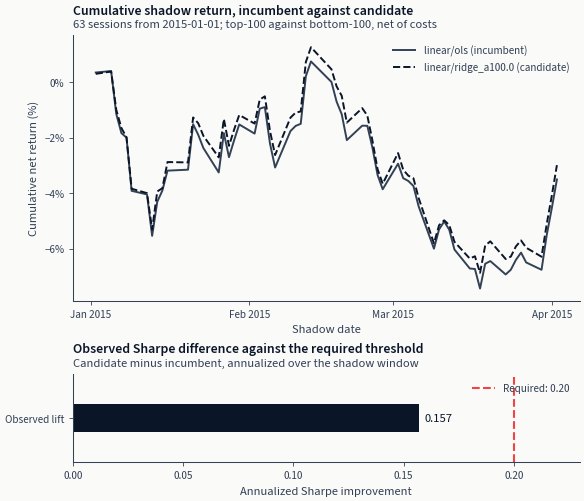

In [26]:
# One horizontal bar needs a third of the height, not half.
fig, axes = plt.subplots(
    2,
    1,
    figsize=FIGSIZE["dual_v"],
    gridspec_kw={"height_ratios": [3, 1]},
    constrained_layout=True,
)
draw_shadow_panel(axes[0])
draw_hurdle_panel(axes[1])
show_with_alt(
    fig,
    "Two stacked panels. Upper: cumulative net return over the shadow window for the "
    "incumbent as a solid grey line and the candidate as a dashed blue line, both as "
    "percentages against a date axis. Lower: a single horizontal bar giving the candidate's "
    "annualized Sharpe improvement over the incumbent, annotated with its value, against a "
    "dashed vertical line at the threshold promotion requires.",
)

## Key Takeaways

1. Write the promotion rule down before the evaluation runs. A threshold chosen after seeing
   the result is not a threshold, and the order the notebook does things in is the only thing
   keeping the two apart.
2. Require a minimum effect, not a positive one. Over sixty-three sessions the standard error
   of an annualized Sharpe estimate is around two, so a gate that promotes on any improvement
   is promoting on sampling noise roughly half the time.
3. Ask whether the candidate is still the same strategy. Scores that correlate with the
   incumbent's and a book that overlaps it are what make this a model upgrade; without them
   the same numbers describe a different exposure, and that is a decision for a person.
4. Charge each model for its own turnover. A candidate that trades more can show a better
   gross number and a worse net one, and the gate has to see the net one.
5. Holding a candidate in shadow is a complete outcome, not a deferral. When one criterion is
   unmet there is nothing to stage and nothing to A/B test, and the candidate keeps running
   with no capital until it clears or is withdrawn.

**Known limitations**

- A shadow window drawn from stored validation predictions is not live shadow mode. The
  candidate never faced a queue, a fill or a data outage, and those are among the things
  shadow mode exists to find.
- Every return here is a close-to-close label return, and the case study enters at the next
  open. Both the level and the difference between the two models are proxies, because the
  two hold different names and so collect different overnight moves.
- Sixty-three sessions is one quarter of one year on one universe. The gate's thresholds are
  defensible in shape and are not calibrated: a desk would set them from its own history of
  promotions and their outcomes.
- The book is a simple ranked long-short at equal weights with a flat per-leg cost. It is not
  the strategy the case study backtests, and its returns should not be read as that strategy's.
- Position agreement is measured over the union of names held, which counts a name held long
  by one model and short by the other as agreement.

**Next**: See `04_circuit_breakers` for the controls that protect models which do qualify for live
operation.